## Variable Diagnostic for Youth Screentime Questionaire variables

Looking for variables that can be used best longitudinally, have the least amount of missing data, and is a good descriptor of overall screentime 

Finding what variables exist for youth screentime questionaire 

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Load wide-format dataset
df = pd.read_csv('/Users/jasmine/Downloads/Thesis-Lab/dataset.tsv', sep='\t', low_memory=False)

# Find all youth screentime variables
stq_vars = [c for c in df.columns if c.startswith('nt_y_stq__')]

print(f"Found {len(stq_vars)} nt_y_stq variables:\n")
for v in stq_vars:
    print(v)

Found 176 nt_y_stq variables:

nt_y_stq__screen__wkdy_005
nt_y_stq__screen__wknd_nm
nt_y_stq__screen__wknd_sum
nt_y_stq__sleep_001
nt_y_stq__sleep_002
nt_y_stq__sleep_003
nt_y_stq__sleep_004
nt_y_stq__sleep_005
nt_y_stq__sleep_006
nt_y_stq__sleep_007
nt_y_stq__sleep_008
nt_y_stq__screen__wkdy_006
nt_y_stq__sleep_009
nt_y_stq__sleep_010
nt_y_stq__sleep_011
nt_y_stq__sleep_012
nt_y_stq__sleep_013
nt_y_stq__sleep_014
nt_y_stq__socmed_001
nt_y_stq__socmed_001__01
nt_y_stq__socmed_001__02
nt_y_stq__socmed_001__03
nt_y_stq__screen__wknd_001
nt_y_stq__socmed_001__04
nt_y_stq__socmed_001__05
nt_y_stq__socmed_001__06
nt_y_stq__socmed_001__07
nt_y_stq__socmed_001__08
nt_y_stq__socmed_001__09
nt_y_stq__socmed_001__10
nt_y_stq__socmed_001__11
nt_y_stq__socmed_002___1
nt_y_stq__socmed_002___2
nt_y_stq__screen__wknd_002
nt_y_stq__socmed_002___3
nt_y_stq__socmed_002___4
nt_y_stq__socmed_002___5
nt_y_stq__socmed_002___6
nt_y_stq__socmed_002___7
nt_y_stq__socmed_002___8
nt_y_stq__socmed_002___9
nt_y_st

dataset configuration

In [3]:
# Configuration for variable diagnostics
SUBJ_COL = 'participant_id'
TP_COL   = 'session_id'
TABLE    = 'nt_y_stq__'

TIMEPOINTS = [
    'ses-000A', 'ses-01A', 'ses-02A',
    'ses-03A',  'ses-04A', 'ses-05A', 'ses-06A'
]

# Subdomain filters (for composite ranking bonus)
SUBDOMAINS = {
    'screen_weekday': 'nt_y_stq__screen__wkdy',
    'screen_weekend': 'nt_y_stq__screen__wknd',
    'sleep':          'nt_y_stq__sleep',
    'social_media':   'nt_y_stq__socmed',
}

# Summary/total score priority flags (for composite ranking bonus)
SUMMARY_KEYWORDS = ['sum', 'tot', 'nm']


Loading the Data 

In [ ]:
df = pd.read_csv('/Users/jasmine/Downloads/Thesis-Lab/dataset.tsv', sep='\t', low_memory=False)

# Get all stq variables
stq_vars = [c for c in df.columns if c.startswith(TABLE)]

# Tag each variable with its subdomain - subdomains are used to categorize variables to see what the possible "types" of variables are
def get_subdomain(var):
    for label, prefix in SUBDOMAINS.items():
        if var.startswith(prefix):
            return label
    return 'other'

# Create a DataFrame to hold variable metadata
var_meta = pd.DataFrame({
    'variable': stq_vars,
    'subdomain': [get_subdomain(v) for v in stq_vars],
    'is_summary': [any(k in v for k in SUMMARY_KEYWORDS) for v in stq_vars]
})

print(f"Total nt_y_stq variables: {len(stq_vars)}")
print(var_meta['subdomain'].value_counts())
print(f"\nSummary/total score variables: {var_meta['is_summary'].sum()}")
print(var_meta[var_meta['is_summary']]['variable'].tolist())

Total nt_y_stq variables: 176
subdomain
screen_weekday    48
screen_weekend    48
social_media      38
other             28
sleep             14
Name: count, dtype: int64

Summary/total score variables: 12
['nt_y_stq__screen__wknd_nm', 'nt_y_stq__screen__wknd_sum', 'nt_y_stq__screen__wkdy__tot__hr_001', 'nt_y_stq__screen__wkdy__tot__min_001', 'nt_y_stq__screen__wkdy__tot__hr_002', 'nt_y_stq__screen__wkdy__tot__min_002', 'nt_y_stq__screen__wknd__tot__hr_001', 'nt_y_stq__screen__wknd__tot__min_001', 'nt_y_stq__screen__wknd__tot__hr_002', 'nt_y_stq__screen__wknd__tot__min_002', 'nt_y_stq__screen__wkdy_nm', 'nt_y_stq__screen__wkdy_sum']


Diagnostic for missingness

In [5]:
print("\n\nRunning missingness diagnostic...")

# Calculate missingness for each variable at each timepoint
miss_records = []
for var in stq_vars:
    for tp, grp in df.groupby(TP_COL):
        if tp not in TIMEPOINTS:
            continue
        n_total   = len(grp)
        n_missing = grp[var].isna().sum()
        miss_records.append({
            'variable':    var,
            'subdomain':   get_subdomain(var),
            'is_summary':  any(k in var for k in SUMMARY_KEYWORDS),
            'timepoint':   tp,
            'n_total':     n_total,
            'n_missing':   n_missing,
            'pct_missing': round(n_missing / n_total * 100, 2)
        })

miss_df      = pd.DataFrame(miss_records)
miss_summary = (miss_df.groupby(['variable', 'subdomain', 'is_summary'])['pct_missing']
                .mean().reset_index()
                .rename(columns={'pct_missing': 'mean_pct_missing'})
                .sort_values('mean_pct_missing'))

print("\n── Top 20 variables by lowest missingness ──")
print(miss_summary.head(20).to_string(index=False))



Running missingness diagnostic...

── Top 20 variables by lowest missingness ──
                            variable      subdomain  is_summary  mean_pct_missing
           nt_y_stq__screen__wknd_nm screen_weekend        True          0.038333
        nt_y_stq__screen__mature_002          other       False          0.100000
        nt_y_stq__screen__mature_001          other       False          0.101667
          nt_y_stq__screen__wknd_sum screen_weekend        True          0.108333
      nt_y_stq__screen__wknd__hr_005 screen_weekend       False         16.706667
      nt_y_stq__screen__wknd__hr_006 screen_weekend       False         16.706667
      nt_y_stq__screen__wknd__hr_008 screen_weekend       False         16.706667
     nt_y_stq__screen__wknd__min_005 screen_weekend       False         16.706667
     nt_y_stq__screen__wknd__min_006 screen_weekend       False         16.706667
     nt_y_stq__screen__wknd__min_008 screen_weekend       False         16.706667
      nt_y_stq__

Longitudinal diagnostic 

In [6]:
print("\n\nRunning longitudinal coverage diagnostic...")

# Calculate longitudinal coverage for each variable
long_records = []
# For each variable, count how many subjects have non-missing data at 1+ waves, 2+ waves, and all waves
for var in stq_vars:
    sub_df       = df[df[TP_COL].isin(TIMEPOINTS)][[SUBJ_COL, TP_COL, var]]
    sub_nonmiss  = sub_df.dropna(subset=[var])
    wave_counts  = sub_nonmiss.groupby(SUBJ_COL)[TP_COL].nunique()

    long_records.append({
        'variable':              var,
        'subdomain':             get_subdomain(var),
        'is_summary':            any(k in var for k in SUMMARY_KEYWORDS),
        'n_subjects_1+_waves':   (wave_counts >= 1).sum(),
        'n_subjects_2+_waves':   (wave_counts >= 2).sum(),
        'n_subjects_complete':   (wave_counts == len(TIMEPOINTS)).sum(),
        'mean_waves_per_subject': round(wave_counts.mean(), 2)
    })

long_df = pd.DataFrame(long_records).sort_values('n_subjects_2+_waves', ascending=False)
print("\n── Top 20 variables by longitudinal coverage ──")
print(long_df.head(20).to_string(index=False))



Running longitudinal coverage diagnostic...

── Top 20 variables by longitudinal coverage ──
                           variable      subdomain  is_summary  n_subjects_1+_waves  n_subjects_2+_waves  n_subjects_complete  mean_waves_per_subject
          nt_y_stq__screen__wknd_nm screen_weekend        True                11541                11185                    0                    4.86
       nt_y_stq__screen__mature_002          other       False                11541                11184                    0                    4.86
       nt_y_stq__screen__mature_001          other       False                11541                11183                    0                    4.86
         nt_y_stq__screen__wknd_sum screen_weekend        True                11538                11183                    0                    4.86
          nt_y_stq__screen__wkdy_nm screen_weekday        True                11533                11126                    0                    3.66
     

Variance diagnostic

In [7]:
print("\n\nRunning variance diagnostic...")

# Calculate variance for each variable at each timepoint, then average across timepoints
var_records = []
for var in stq_vars:
    tp_variances = []
    for tp, grp in df.groupby(TP_COL):
        if tp not in TIMEPOINTS:
            continue
        v = grp[var].var()
        if not np.isnan(v):
            tp_variances.append(v)
    var_records.append({
        'variable':      var,
        'subdomain':     get_subdomain(var),
        'is_summary':    any(k in var for k in SUMMARY_KEYWORDS),
        'mean_variance': round(np.nanmean(tp_variances), 4) if tp_variances else np.nan
    })

# Create DataFrame and sort by mean variance
var_df = pd.DataFrame(var_records).sort_values('mean_variance', ascending=False)
print("\n── Top 20 variables by variance ──")
print(var_df.head(20).to_string(index=False))



Running variance diagnostic...

── Top 20 variables by variance ──
                variable    subdomain  is_summary  mean_variance
    nt_y_stq__socmed_005 social_media       False   3.185049e+12
    nt_y_stq__socmed_006 social_media       False   2.453341e+07
       nt_y_stq__dlt_001        other       False   1.028490e+05
    nt_y_stq__socmed_004 social_media       False   9.204891e+04
     nt_y_stq__sleep_002        sleep       False   2.280746e+04
  nt_y_stq__creative_002        other       False   1.310536e+04
  nt_y_stq__creative_001        other       False   1.295371e+04
     nt_y_stq__sleep_014        sleep       False   1.120160e+04
     nt_y_stq__sleep_013        sleep       False   1.011194e+04
      nt_y_stq__dapp_001        other       False   9.419150e+03
    nt_y_stq__socmed_007 social_media       False   4.944822e+03
    nt_y_stq__socmed_003 social_media       False   3.576792e+03
     nt_y_stq__phone_009        other       False   3.519496e+03
      nt_y_stq__dapp_

composite ranking

In [ ]:
print("\n\nBuilding composite ranking...")

# Normalize each metric to 0-1 (higher is better), then combine with weights
scaler  = MinMaxScaler()
ranking = miss_summary.merge(long_df[['variable', 'n_subjects_2+_waves', 'mean_waves_per_subject']], on='variable', how='left')
ranking = ranking.merge(var_df[['variable', 'mean_variance']], on='variable', how='left')

ranking['miss_score'] = 1 - scaler.fit_transform(ranking[['mean_pct_missing']])
ranking['long_score'] = scaler.fit_transform(ranking[['n_subjects_2+_waves']])
ranking['var_score']  = scaler.fit_transform(ranking[['mean_variance']])

# Summary score bonus (+0.1) to prioritize aggregate variables per your goal
ranking['summary_bonus'] = ranking['is_summary'].astype(float) * 0.10

ranking['composite_score'] = (
    ranking['miss_score']    * 0.30 +
    ranking['long_score']    * 0.30 +
    ranking['var_score']     * 0.20 +
    ranking['summary_bonus']
)

final = ranking.sort_values('composite_score', ascending=False)

print("\n══ FINAL VARIABLE RANKING (Top 30) ══")
print(final[['variable', 'subdomain', 'is_summary', 'composite_score',
             'mean_pct_missing', 'n_subjects_2+_waves',
             'mean_variance']].head(30).to_string(index=False))

# Save full ranking
final.to_csv('stq_variable_diagnostic.csv', index=False)
print("\n✓ Full ranking saved to stq_variable_diagnostic.csv")



Building composite ranking...

══ FINAL VARIABLE RANKING (Top 30) ══
                            variable      subdomain  is_summary  composite_score  mean_pct_missing  n_subjects_2+_waves  mean_variance
           nt_y_stq__screen__wknd_nm screen_weekend        True         0.700000          0.038333                11185         0.0094
          nt_y_stq__screen__wknd_sum screen_weekend        True         0.699735          0.108333                11183       104.0369
nt_y_stq__screen__wknd__tot__min_001 screen_weekend        True         0.639712         16.708333                10810       207.2311
 nt_y_stq__screen__wknd__tot__hr_001 screen_weekend        True         0.639712         16.708333                10810        16.9376
nt_y_stq__screen__wkdy__tot__min_001 screen_weekday        True         0.639707         16.710000                10810       205.3880
 nt_y_stq__screen__wkdy__tot__hr_001 screen_weekday        True         0.639707         16.710000                10810

missingness heatmap

Timepoints present in heatmap: ['ses-01A', 'ses-02A', 'ses-03A', 'ses-04A', 'ses-05A', 'ses-06A']
Summary variables in heatmap: 12


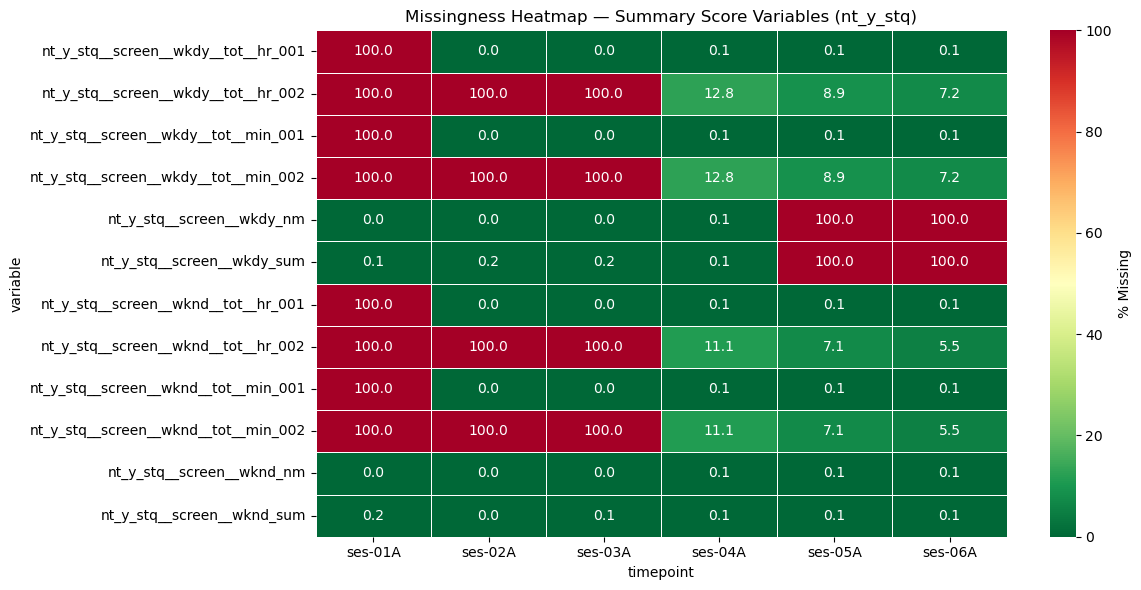

✓ Heatmap saved to stq_missingness_heatmap.png


In [9]:
# ── HEATMAP: Missingness by variable × timepoint ─────────────────────────────
summary_vars = var_meta[var_meta['is_summary']]['variable'].tolist()

# Create pivot table for heatmap - this will automatically exclude any timepoints that don't have data for these variables
pivot = miss_df[miss_df['variable'].isin(summary_vars)].pivot_table(
    index='variable', columns='timepoint', values='pct_missing'
)

# Only keep timepoints that actually exist in the pivot columns
available_timepoints = [tp for tp in TIMEPOINTS if tp in pivot.columns]
pivot = pivot[available_timepoints]

print(f"Timepoints present in heatmap: {available_timepoints}")
print(f"Summary variables in heatmap: {len(pivot)}")

plt.figure(figsize=(12, max(6, len(pivot) * 0.4)))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': '% Missing'})
plt.title('Missingness Heatmap — Summary Score Variables (nt_y_stq)')
plt.tight_layout()
plt.savefig('stq_missingness_heatmap.png', dpi=150)
plt.show()
print("✓ Heatmap saved to stq_missingness_heatmap.png") 